# 03 — Regression Modeling

Predict `average_utilization` using a time-aware split. Compare baselines, linear, tree/boosting, neural network, and a stacking ensemble. Includes individual-learning sections for calendar ablation, Optuna tuning, and ensemble analysis.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if (ROOT / "rec_center_utils.py").exists():
    pass
elif (ROOT / "rec_center" / "rec_center_utils.py").exists():
    ROOT = ROOT / "rec_center"
elif (ROOT.parent / "rec_center_utils.py").exists():
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not locate rec_center_utils.py")
sys.path.insert(0, str(ROOT))

from rec_center_utils import (
    TRAIN_END,
    VAL_END,
    clean_data,
    data_path,
    figures_path,
    load_clean_data,
    load_raw_data,
    save_clean_data,
)

sns.set_theme(style="whitegrid", context="notebook")

import json
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from rec_center_utils import RANDOM_STATE, get_feature_frame

METRICS_PATH = ROOT / "data" / "metrics.json"



c:\Users\tyler\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:

df = load_clean_data()
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]

feature_cols = get_feature_frame(train_df).columns.tolist()
numeric_cols = [c for c in feature_cols if c != "location"]
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["location"]),
    ("num", "passthrough", numeric_cols),
])

X_train = get_feature_frame(train_df)
X_val = get_feature_frame(val_df)
X_test = get_feature_frame(test_df)
y_train = train_df["average_utilization"].values
y_val = val_df["average_utilization"].values
y_test = test_df["average_utilization"].values

preprocessor.fit(X_train)
X_train_mat = preprocessor.transform(X_train)
X_val_mat = preprocessor.transform(X_val)
X_test_mat = preprocessor.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_mat)
X_val_scaled = scaler.transform(X_val_mat)
X_test_scaled = scaler.transform(X_test_mat)

def metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }



## Baseline: historical mean by location × weekday × hour


In [3]:

means = train_df.groupby(["location", "day_of_week", "hour"])["average_utilization"].mean().reset_index(name="pred")
base = test_df.merge(means, on=["location", "day_of_week", "hour"], how="left")
base["pred"] = base["pred"].fillna(train_df["average_utilization"].mean())
baseline_metrics = metrics(y_test, base["pred"].values)
baseline_metrics



{'rmse': 0.28947733020169847,
 'mae': 0.24690846349113257,
 'r2': 0.29082828589211873}

## Linear and tree/boosting models with tuning


In [4]:

results = []

ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge()),
])
ridge_search = RandomizedSearchCV(ridge, {"model__alpha": np.logspace(-3, 2, 20)}, n_iter=10, scoring="neg_root_mean_squared_error", cv=3, random_state=RANDOM_STATE)
ridge_search.fit(X_train, y_train)
ridge_best = ridge_search.best_estimator_
results.append({"model": "ridge", **metrics(y_test, ridge_best.predict(X_test))})

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_search = RandomizedSearchCV(
    rf,
    {"model__n_estimators": [100, 200, 300], "model__max_depth": [8, 12, 16, None], "model__min_samples_leaf": [1, 2, 5]},
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
results.append({"model": "random_forest", **metrics(y_test, rf_best.predict(X_test))})

lgbm = Pipeline([
    ("prep", preprocessor),
    ("model", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)),
])
lgbm_search = RandomizedSearchCV(
    lgbm,
    {"model__n_estimators": [200, 400, 600], "model__learning_rate": [0.03, 0.05, 0.1], "model__num_leaves": [31, 63, 127], "model__subsample": [0.7, 0.9, 1.0]},
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
results.append({"model": "lightgbm", **metrics(y_test, lgbm_best.predict(X_test))})

cat = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)),
])
cat_search = RandomizedSearchCV(
    cat,
    {"model__depth": [6, 8, 10], "model__learning_rate": [0.03, 0.05, 0.1], "model__iterations": [300, 500, 700], "model__l2_leaf_reg": [1, 3, 5]},
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
cat_search.fit(X_train, y_train)
cat_best = cat_search.best_estimator_
results.append({"model": "catboost", **metrics(y_test, cat_best.predict(X_test))})

pd.DataFrame(results).sort_values("rmse")



c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(X

,model,rmse,mae,r2
3,catboost,0.125130,0.088031,0.867491
2,lightgbm,0.127639,0.088038,0.862125
1,random_forest,0.133988,0.089699,0.848065
0,ridge,0.219231,0.175332,0.593252


## Individual learning — Member A: Academic calendar ablation

Compare LightGBM with and without academic calendar flags to quantify their value.


In [5]:

no_cal_cols = get_feature_frame(train_df, include_calendar=False).columns.tolist()
no_cal_numeric = [c for c in no_cal_cols if c != "location"]
no_cal_prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["location"]),
    ("num", "passthrough", no_cal_numeric),
])
no_cal_pipe = Pipeline([
    ("prep", no_cal_prep),
    ("model", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, **{k.replace("model__", ""): v for k, v in lgbm_search.best_params_.items()})),
])
no_cal_pipe.fit(get_feature_frame(train_df, include_calendar=False), y_train)
ablation = pd.DataFrame([
    {"features": "with_calendar", **metrics(y_test, lgbm_best.predict(X_test))},
    {"features": "without_calendar", **metrics(y_test, no_cal_pipe.predict(get_feature_frame(test_df, include_calendar=False)))},
])
ablation



c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,features,rmse,mae,r2
0,with_calendar,0.127639,0.088038,0.862125
1,without_calendar,0.144907,0.095986,0.822294


## Individual learning — Member B: Optuna tuning for Keras MLP

Neural networks benefit from architecture search; Optuna explores units, dropout, and learning rate efficiently.


In [6]:

import optuna
import tensorflow as tf
from tensorflow.keras import layers

optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.keras.utils.set_random_seed(RANDOM_STATE)

def build_mlp(params):
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(params["units_1"], activation="relu"),
        layers.Dropout(params["dropout"]),
        layers.Dense(params["units_2"], activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(params["learning_rate"]), loss="mse")
    return model

def objective(trial):
    params = {
        "units_1": trial.suggest_int("units_1", 32, 128, step=32),
        "units_2": trial.suggest_int("units_2", 16, 64, step=16),
        "dropout": trial.suggest_float("dropout", 0.1, 0.4),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True),
    }
    model = build_mlp(params)
    model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=15, batch_size=1024, verbose=0)
    preds = model.predict(X_val_scaled, verbose=0).ravel()
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)
nn_best = build_mlp(study.best_params)
nn_best.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=20, batch_size=1024, verbose=0)
nn_preds = nn_best.predict(X_test_scaled, verbose=0).ravel()
results.append({"model": "keras_mlp", **metrics(y_test, nn_preds)})
study.best_params



{'units_1': 128,
 'units_2': 64,
 'dropout': 0.23668307922677487,
 'learning_rate': 0.004613309540348341}

## Individual learning — Member C: Stacking ensemble

Stack diverse base learners (LightGBM, CatBoost, Keras MLP) with a Ridge meta-learner fit on validation predictions.


In [7]:

val_stack = np.column_stack([
    lgbm_best.predict(X_val),
    cat_best.predict(X_val),
    nn_best.predict(X_val_scaled, verbose=0).ravel(),
])
test_stack = np.column_stack([
    lgbm_best.predict(X_test),
    cat_best.predict(X_test),
    nn_preds,
])
meta = Ridge(alpha=1.0)
meta.fit(val_stack, y_val)
ensemble_preds = meta.predict(test_stack)
results.append({"model": "stacking_ensemble", **metrics(y_test, ensemble_preds)})

regression_table = pd.DataFrame(results).sort_values("rmse")
regression_table



c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,rmse,mae,r2
5,stacking_ensemble,0.122959,0.088668,0.872050
3,catboost,0.125130,0.088031,0.867491
2,lightgbm,0.127639,0.088038,0.862125
1,random_forest,0.133988,0.089699,0.848065
4,keras_mlp,0.141728,0.102001,0.830006
0,ridge,0.219231,0.175332,0.593252


## Neural vs non-neural comparison (peak weekday hours)


c:\Users\tyler\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


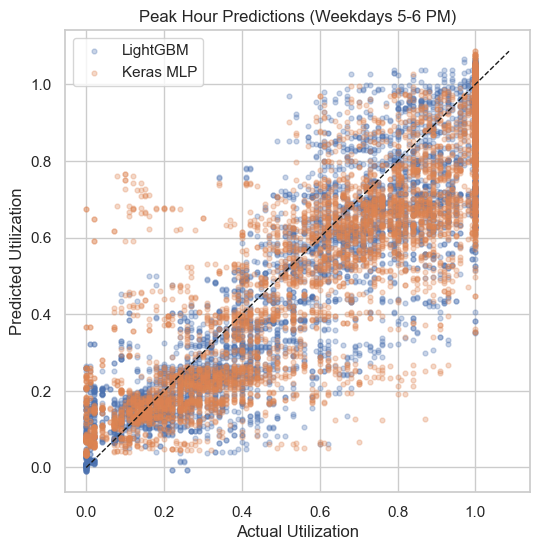

In [8]:

peak = test_df[(test_df["hour"].between(17, 18)) & (test_df["day_of_week"] < 5)].copy()
peak_true = peak["average_utilization"].values
peak_lgbm = lgbm_best.predict(get_feature_frame(peak))
peak_nn = nn_best.predict(scaler.transform(preprocessor.transform(get_feature_frame(peak))), verbose=0).ravel()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(peak_true, peak_lgbm, alpha=0.3, label="LightGBM", s=12)
ax.scatter(peak_true, peak_nn, alpha=0.3, label="Keras MLP", s=12)
lims = [0, max(peak_true.max(), peak_lgbm.max(), peak_nn.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Actual Utilization")
ax.set_ylabel("Predicted Utilization")
ax.set_title("Peak Hour Predictions (Weekdays 5-6 PM)")
ax.legend()
fig.savefig(figures_path("peak_hour_pred_vs_actual.png"), dpi=150, bbox_inches="tight")
plt.show()

